# Feedforward Neural Network -- Taxi Demand Prediction

Counterpart to [03.08_prediction_svm_full_pipeline.ipynb](03.08_prediction_svm_full_pipeline.ipynb):
same Chicago taxi + weather data (2024-01 to 2026-05), feature set, baseline, and evaluation
metrics, with a feedforward neural network in place of the SVM.

1. Data preparation (demand panel, cyclical + one-hot time encoding, weather, demand-threshold
   filter, spatial one-hot, chronological split: 2024-2025 train, Jan-May 2026 test)
2. Demand-weighted baseline
3. Shallow NN (one hidden layer), cyclical vs. one-hot time encoding
4. Deep NN (two hidden layers, dropout, weight decay), tuned by a small hyperparameter search
5. Resolution sensitivity (community area vs. census tract; 4h vs. 1h buckets)
6. Discussion

As in 03.08: no lagged/historical-demand features (purely exogenous signal), and one pooled
model with one-hot spatial dummies rather than a model per area.


## Imports and Configuration

In [30]:
import time
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TAXI_DATA_PATH       = "../../data/chicago_taxi_2024_2026_clean.parquet"
WEATHER_DATA_PATH    = "../../data/chicago_weather_2024_2026_hourly.csv"

# Data range covered by the cleaned parquet (June 2026+ excluded: portal reporting lag)
DATA_START    = pd.Timestamp("2024-01-01")
DATA_END_EXCL = pd.Timestamp("2026-06-01")

# Test boundary, identical to 03.08: 2024-2025 for fitting, Jan-May 2026 held out as test
TEST_START = pd.Timestamp("2025-12-31")

WEATHER_COLS      = ["temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover"]
DEMAND_THRESHOLD  = 10     # median trips / 4h window, same cutoff used elsewhere in this project
FREQ              = "4h"   # primary temporal resolution; section 5 varies this
LOG_PRED_CAP      = 20     # overflow guard for expm1 back-transform on an unstable model's output
CATEGORICAL_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

NN_MAX_EPOCHS = 200  # upper bound; early stopping (Section 3.1) almost always stops well before this
NN_PATIENCE   = 8    # epochs without early-stopping-slice improvement before stopping
NN_BATCH_SIZE = 512

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

print(f"train: {DATA_START.date()} to {TEST_START.date()}  "
      f"test: {TEST_START.date()} to {DATA_END_EXCL.date()}")

# Evaluation week for baseline comparison
EVAL_WEEK_START = pd.Timestamp("2026-03-02")
EVAL_WEEK_END   = EVAL_WEEK_START + pd.Timedelta(days=7)


Using device: cpu
train: 2024-01-01 to 2025-12-31  test: 2025-12-31 to 2026-06-01


## 1. Data Preparation

Load trips + weather, build a zero-filled (spatial unit x time window) demand panel carrying
both time encodings (cyclical and one-hot), filter to units with enough signal, and split
chronologically. Same preparation as 03.08.


In [31]:
# US federal holidays (incl. observed dates), computed for every year the data covers --
US_HOLIDAYS = pd.DatetimeIndex(sorted(
    holidays.US(years=range(DATA_START.year, DATA_END_EXCL.year + 1))
))

taxi = pd.read_parquet(
    TAXI_DATA_PATH,
    columns=["trip_start_timestamp", "pickup_community_area", "pickup_census_tract"],
)

taxi_ca = taxi[taxi["pickup_community_area"].notna()].copy()
taxi_ca["pickup_community_area"] = taxi_ca["pickup_community_area"].astype(int)
print(f"Trips with pickup community area: {len(taxi_ca):,} of {len(taxi):,} "
      f"({len(taxi_ca)/len(taxi)*100:.1f}%)")

weather = pd.read_csv(WEATHER_DATA_PATH)
weather["datetime"] = pd.to_datetime(weather["datetime"])
weather = weather[["datetime"] + WEATHER_COLS]


def build_panel(trips, src_col, unit_col, units, freq):
    """Zero-filled (unit, time window) demand grid + weather + both time encodings (cyclical
    sin/cos and one-hot dummies for hour/day-of-week/month). Spatial one-hot depends on the
    demand-threshold filter and is built later, in Feature encoding. Same as 03.08."""
    window = trips["trip_start_timestamp"].dt.floor(freq).rename("timestamp")
    counts = trips.groupby([trips[src_col].rename(unit_col), window]).size().rename("count")

    all_windows = pd.date_range(DATA_START, DATA_END_EXCL, freq=freq, inclusive="left")
    grid = pd.MultiIndex.from_product([units, all_windows], names=[unit_col, "timestamp"])
    panel = counts.reindex(grid, fill_value=0).reset_index()

    w = weather.copy()
    w["timestamp"] = w["datetime"].dt.floor(freq)
    w_agg = w.groupby("timestamp")[WEATHER_COLS].mean().reset_index()
    panel = panel.merge(w_agg, on="timestamp", how="left")
    panel[WEATHER_COLS] = panel[WEATHER_COLS].ffill().bfill()

    panel["hour"]        = panel["timestamp"].dt.hour
    panel["day_of_week"]  = panel["timestamp"].dt.dayofweek
    panel["month"]        = panel["timestamp"].dt.month
    # hour_frac (not just hour) keeps the cyclical encoding correct at sub-hour resolutions too
    hour_frac = panel["hour"] + panel["timestamp"].dt.minute / 60.0

    panel["hour_sin"]        = np.sin(2 * np.pi * hour_frac / 24)
    panel["hour_cos"]        = np.cos(2 * np.pi * hour_frac / 24)
    panel["day_of_week_sin"] = np.sin(2 * np.pi * panel["day_of_week"] / 7)
    panel["day_of_week_cos"] = np.cos(2 * np.pi * panel["day_of_week"] / 7)
    panel["month_sin"]       = np.sin(2 * np.pi * panel["month"] / 12)
    panel["month_cos"]       = np.cos(2 * np.pi * panel["month"] / 12)
    panel["is_weekend"]      = (panel["day_of_week"] >= 5).astype(int)
    panel["is_holiday"]      = panel["timestamp"].dt.date.isin(US_HOLIDAYS.date).astype(int)

    # One-hot dummies for the same three fields, built right alongside their cyclical counterparts
    # so every panel this function produces carries both time encodings consistently.
    hour_dummies  = pd.get_dummies(panel["hour"], prefix="hour", drop_first=True).astype(float)
    dow_dummies   = pd.get_dummies(panel["day_of_week"], prefix="dow", drop_first=True).astype(float)
    month_dummies = pd.get_dummies(panel["month"], prefix="month", drop_first=True).astype(float)
    panel = pd.concat([panel, hour_dummies, dow_dummies, month_dummies], axis=1)

    return panel.sort_values([unit_col, "timestamp"]).reset_index(drop=True)

t0 = time.time()
panel_ca = build_panel(taxi_ca, "pickup_community_area", "community_area", np.arange(1, 78), FREQ)
print(f"Panel built in {time.time()-t0:.1f}s: {len(panel_ca):,} rows "
      f"({panel_ca['community_area'].nunique()} areas x {panel_ca['timestamp'].nunique():,} windows)")


Trips with pickup community area: 14,201,846 of 14,465,650 (98.2%)
Panel built in 1.4s: 407,484 rows (77 areas x 5,292 windows)


In [32]:
panel_ca.info()

<class 'pandas.DataFrame'>
RangeIndex: 407484 entries, 0 to 407483
Data columns (total 41 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   community_area   407484 non-null  int64         
 1   timestamp        407484 non-null  datetime64[us]
 2   count            407484 non-null  int64         
 3   temperature_2m   407484 non-null  float64       
 4   precipitation    407484 non-null  float64       
 5   snowfall         407484 non-null  float64       
 6   wind_speed_10m   407484 non-null  float64       
 7   cloud_cover      407484 non-null  float64       
 8   hour             407484 non-null  int32         
 9   day_of_week      407484 non-null  int32         
 10  month            407484 non-null  int32         
 11  hour_sin         407484 non-null  float64       
 12  hour_cos         407484 non-null  float64       
 13  day_of_week_sin  407484 non-null  float64       
 14  day_of_week_cos  407484 non-nul

### Demand-threshold filter

Only community areas with median demand >= 10 trips per 4h window are kept; areas below have
too little signal (mostly zeros) to model. Same cutoff as 03.08.


Included areas (median >= 10/4h): 20 of 77 -> [1, 2, 3, 6, 7, 8, 22, 24, 28, 32, 33, 35, 38, 41, 43, 44, 56, 69, 76, 77]


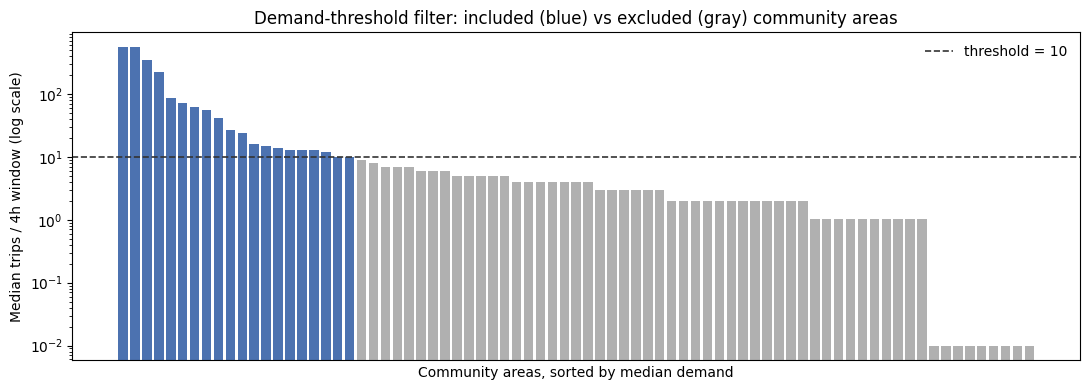

In [33]:
area_stats = panel_ca.groupby("community_area")["count"].agg(median="median", mean="mean")
included_areas = sorted(area_stats.index[area_stats["median"] >= DEMAND_THRESHOLD].tolist())
print(f"Included areas (median >= {DEMAND_THRESHOLD}/4h): {len(included_areas)} of 77 -> {included_areas}")

sorted_stats = area_stats.sort_values("median", ascending=False)
colors = [CATEGORICAL_COLORS[0] if m >= DEMAND_THRESHOLD else "#B0B0B0" for m in sorted_stats["median"]]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(sorted_stats)), sorted_stats["median"] + 0.01, color=colors, width=0.8)
ax.axhline(y=DEMAND_THRESHOLD, color="#333333", linestyle="--", linewidth=1.2, label=f"threshold = {DEMAND_THRESHOLD}")
ax.set_yscale("log")
ax.set_xticks([])
ax.set_xlabel("Community areas, sorted by median demand")
ax.set_ylabel("Median trips / 4h window (log scale)")
ax.set_title("Demand-threshold filter: included (blue) vs excluded (gray) community areas")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Feature encoding

`build_panel` already attached both time encodings. Spatial one-hot dummies are built here,
from the areas that survive the filter. Weather is used as-is; no lag features.
`make_preprocess` returns a fresh, unfit ColumnTransformer so each fitting stage gets its own
scaler.


In [34]:
panel = panel_ca[panel_ca["community_area"].isin(included_areas)].reset_index(drop=True)

# Spatial one-hot dummies
area_dummies = pd.get_dummies(panel["community_area"], prefix="area", drop_first=True).astype(float)
AREA_DUMMY_COLS = list(area_dummies.columns)
panel = pd.concat([panel, area_dummies], axis=1)

TIME_DUMMY_COLS = [c for c in panel.columns
                   if c.startswith(("hour_", "dow_", "month_")) and not c.endswith(("sin", "cos"))]

# Cyclical time-encoding variant: continuous weather features, cyclical time columns, plus the
# spatial one-hot dummies. Compared against the one-hot variant below throughout Section 3.
CE_CONT_FEATURES = [
    "temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover",
    "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos", "month_sin", "month_cos",
    "is_weekend", "is_holiday",
]
CE_ALL_COLS = CE_CONT_FEATURES + AREA_DUMMY_COLS

# One-hot time-encoding variant: same continuous/weather features minus the cyclical columns,
# plus the hour/day-of-week/month dummies instead. Compared against the cyclical variant above
# throughout Section 3.
OH_CONT_FEATURES = [
    "temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover",
    "is_weekend", "is_holiday",
]
OH_ALL_COLS = OH_CONT_FEATURES + TIME_DUMMY_COLS + AREA_DUMMY_COLS


def make_preprocess(cont_features, dummy_cols):
    """Fresh, unfit ColumnTransformer -- scales the continuous features, passes the dummy
    columns through unscaled. Each fitting stage gets its own instance."""
    return ColumnTransformer([
        ("scale", StandardScaler(), cont_features),
        ("dummies", "passthrough", dummy_cols),
    ])


print(f"Cyclical: {len(CE_CONT_FEATURES)} continuous features + {len(AREA_DUMMY_COLS)} area dummies "
      f"= {len(CE_ALL_COLS)} total features, {len(panel):,} rows")
print(f"One-Hot: {len(OH_CONT_FEATURES)} continuous features + {len(TIME_DUMMY_COLS)} time dummies + "
      f"{len(AREA_DUMMY_COLS)} area dummies = {len(OH_ALL_COLS)} total features, {len(panel):,} rows")


Cyclical: 13 continuous features + 19 area dummies = 32 total features, 105,840 rows
One-Hot: 7 continuous features + 22 time dummies + 19 area dummies = 48 total features, 105,840 rows


In [35]:
train_val = panel[panel["timestamp"] < TEST_START].reset_index(drop=True)
test      = panel[panel["timestamp"] >= TEST_START].reset_index(drop=True)

for name, df in [("train", train_val), ("test", test)]:
    print(f"{name:5s}: {len(df):7,} rows  {df['timestamp'].min().date()} to {df['timestamp'].max().date()}  "
          f"({len(df)/len(panel)*100:.1f}%)")


train:  87,600 rows  2024-01-01 to 2025-12-30  (82.8%)
test :  18,240 rows  2025-12-31 to 2026-05-31  (17.2%)


### Shared evaluation helpers

`weighted_rmse` weights each row by its unit's training-period mean demand, so high-volume
areas drive the headline metric. Same metrics and weights as 03.08.


In [36]:
UNIT_COL = "community_area"
UNIT_WEIGHT = train_val.groupby(UNIT_COL)["count"].mean()  # historical (pre-test) demand volume


def weighted_rmse(y_true, y_pred, weights):
    return float(np.sqrt(np.average((np.asarray(y_true) - np.asarray(y_pred)) ** 2, weights=weights)))


def evaluate(df, y_pred, unit_col=UNIT_COL, unit_weight=UNIT_WEIGHT):
    y_true = df["count"].to_numpy(dtype=float)
    w = df[unit_col].map(unit_weight).fillna(unit_weight.mean()).to_numpy()
    return {
        "rmse":          float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae":           float(mean_absolute_error(y_true, y_pred)),
        "r2":            float(r2_score(y_true, y_pred)),
        "weighted_rmse": weighted_rmse(y_true, y_pred, w),
    }


def predict_counts(model, X):
    """Back-transform log1p-scale predictions to trip counts, clipped at 0 (and capped
    pre-expm1 to avoid overflow). `model` only needs a `.predict(X)` method (see
    `TorchRegressor` in Section 3)."""
    y_log = np.clip(model.predict(X), -LOG_PRED_CAP, LOG_PRED_CAP)
    return np.clip(np.expm1(y_log), 0, None)


def results_row(name, m_test, fit_time):
    return {
        "model": name, "fit_time_s": round(fit_time, 2),
        "test_rmse": m_test["rmse"], "test_mae": m_test["mae"], "test_r2": m_test["r2"],
        "test_weighted_rmse": m_test["weighted_rmse"],
    }


all_results = []


## 2. Baseline Model

Predicts each area's training-period median demand for its (hour bucket, day of week, month)
combination. All models below are read against this baseline. Identical to 03.08.


### 2.1 Baseline Calculation

In [37]:
t0 = time.time()

BASELINE_BUCKET_COLS = ["hour", "day_of_week", "month"]

def baseline_weight_from(df, unit_col=UNIT_COL, bucket_cols=BASELINE_BUCKET_COLS):
    return df.groupby([unit_col] + bucket_cols)["count"].median()

def baseline_predict(df, weight, unit_col=UNIT_COL, bucket_cols=BASELINE_BUCKET_COLS):
    idx = pd.MultiIndex.from_frame(df[[unit_col] + bucket_cols])
    pred = weight.reindex(idx).to_numpy()
    return np.where(np.isnan(pred), weight.median(), pred)


BASELINE_WEIGHT = baseline_weight_from(train_val)

test_pred_base = baseline_predict(test, BASELINE_WEIGHT)
m_test_base = evaluate(test, test_pred_base)
fit_time_base = time.time() - t0

all_results.append(results_row("Weighted baseline", m_test_base, fit_time_base))
print("Baseline test:", m_test_base)


Baseline test: {'rmse': 76.36268519533103, 'mae': 32.90276864035088, 'weighted_rmse': 150.86146317196142}


### 2.2 Baseline Performance

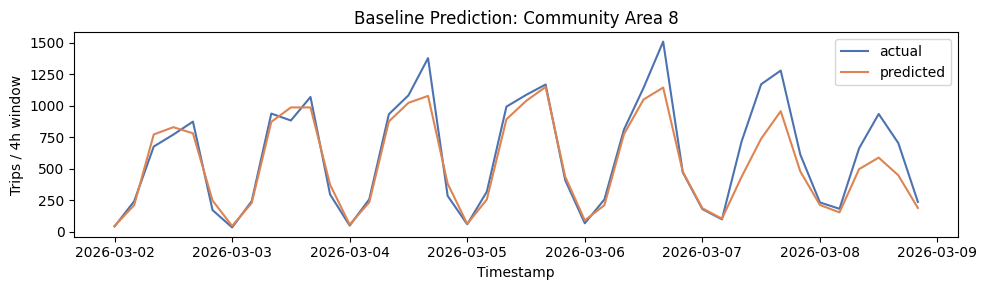

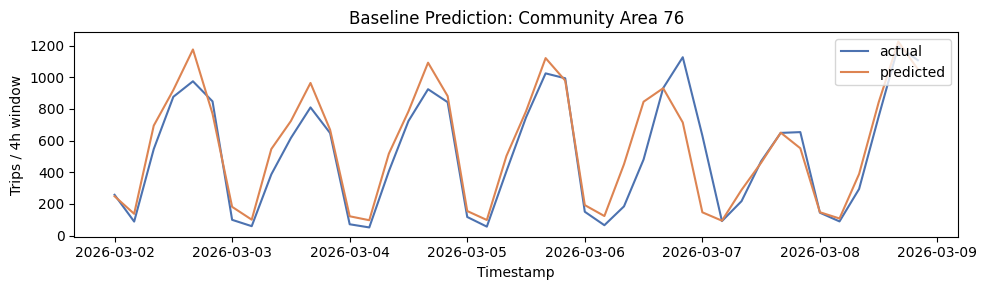

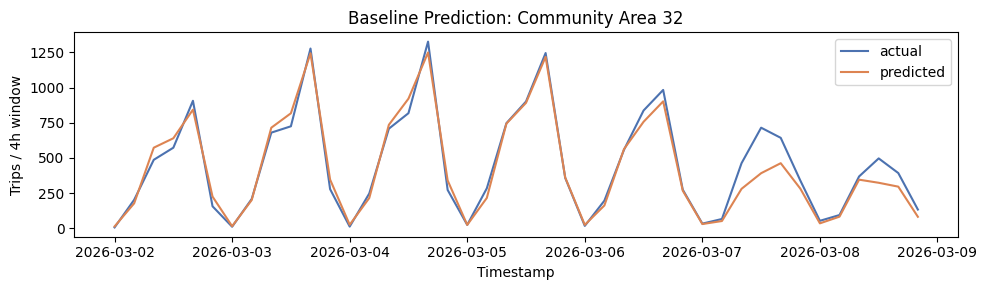

In [38]:
# Show actual vs predicted counts for the top 3 community areas for a week in the test set

test_plot = test[(test["timestamp"] >= EVAL_WEEK_START) & (test["timestamp"] < EVAL_WEEK_END)].reset_index(drop=True)
test_plot_pred_base = baseline_predict(test_plot, BASELINE_WEIGHT)

# Get the top 3 community areas by median demand in the test set
top_3_areas = test_plot.groupby("community_area")["count"].median().sort_values(ascending=False).head(3).index

for i, area in enumerate(top_3_areas):
    mask = test_plot["community_area"] == area
    area_val = test_plot[mask]
    area_pred = test_plot_pred_base[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=CATEGORICAL_COLORS[0])
    ax.plot(area_val["timestamp"], area_pred, label="predicted", color=CATEGORICAL_COLORS[1])
    ax.set_title(f"Baseline Prediction: Community Area {area}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Trips / 4h window")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


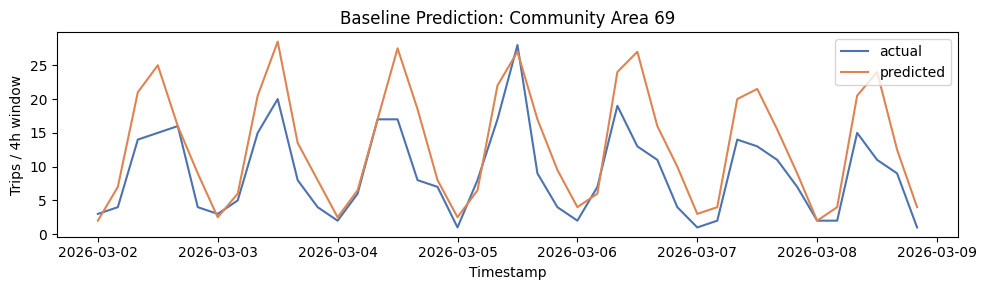

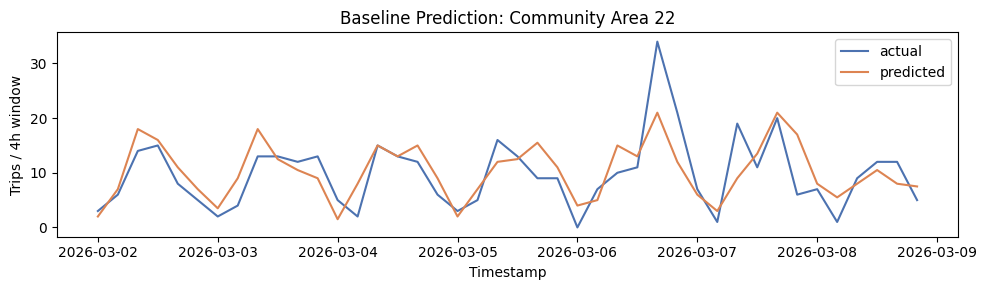

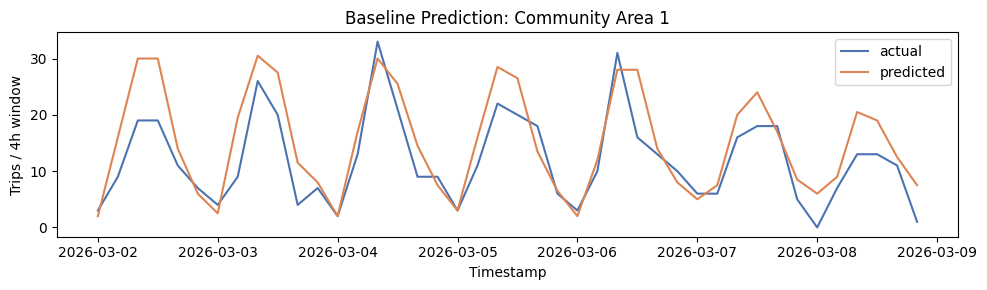

In [39]:
# Show actual vs predicted counts for the bottom 3 community areas for the same test week

bottom_3_areas = test_plot.groupby("community_area")["count"].median().sort_values(ascending=True).head(3).index

for i, area in enumerate(bottom_3_areas):
    mask = test_plot["community_area"] == area
    area_val = test_plot[mask]
    area_pred = test_plot_pred_base[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=CATEGORICAL_COLORS[0])
    ax.plot(area_val["timestamp"], area_pred, label="predicted", color=CATEGORICAL_COLORS[1])
    ax.set_title(f"Baseline Prediction: Community Area {area}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Trips / 4h window")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


Baseline test-set metrics: RMSE 76.4, MAE 32.9, weighted RMSE 150.9 -- the bar every model
below has to beat. The plots show the baseline tracks the daily double-peak rhythm closely in
the high-volume areas but underestimates the strongest weekend peaks; in the low-volume areas
(under ~30 trips per window) its predictions are proportionally noisier.


## 3. Shallow Neural Network

A pooled feedforward network (one hidden layer, ReLU) over all included areas, predicting
`log1p(count)`. Continuous features are standardized; dummies pass through unscaled. Both time
encodings are fit side by side and compared.


### Shared NN training machinery

Each model is trained exactly once: `train_val` (2024-2025) is split randomly 80/20 into
`nn_fit`/`nn_es`; training runs on `nn_fit` with early stopping on `nn_es`, the best-epoch
weights are restored, and that model is evaluated once on `test`. The split can be random
because there are no lag features. There is no refit, so the chosen epoch count is only ever
applied at the dataset size it was validated on.


In [40]:
# Random 80/20 split of the training data. nn_es is used only for early stopping and, later,
# permutation importance -- it never receives weight updates.
nn_fit, nn_es = train_test_split(train_val, test_size=0.2, shuffle=True, random_state=SEED)
nn_fit = nn_fit.reset_index(drop=True)
nn_es  = nn_es.reset_index(drop=True)
print(f"nn_fit: {len(nn_fit):,} rows (random 80% of train_val)")
print(f"nn_es:  {len(nn_es):,} rows (random 20% of train_val)")


def make_xy(df, cols, preprocess_obj, fit=False):
    """DataFrame -> (X, y) torch tensors with log1p-transformed y. `fit=True` fits
    `preprocess_obj` on this frame (only ever training splits, never nn_es/test)."""
    Xs = (preprocess_obj.fit_transform(df[cols]) if fit else preprocess_obj.transform(df[cols])).astype(np.float32)
    y = np.log1p(df["count"].to_numpy(dtype=np.float32))
    return torch.from_numpy(Xs), torch.from_numpy(y)


class TorchRegressor:
    """Wraps a trained torch model + its fitted ColumnTransformer behind a sklearn-style
    .predict(X), so predict_counts/evaluate work unchanged."""
    def __init__(self, model, preprocess_obj):
        self.model, self.preprocess_obj = model, preprocess_obj

    def predict(self, X):
        Xs = self.preprocess_obj.transform(X).astype(np.float32)
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.from_numpy(Xs).to(device)).cpu().numpy()


nn_fit: 70,080 rows (random 80% of train_val)
nn_es:  17,520 rows (random 20% of train_val)


In [41]:
class ShallowNet(nn.Module):
    """One hidden layer + ReLU -- Section 3's model."""
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x))).squeeze(-1)


class DeepNet(nn.Module):
    """Two hidden layers + dropout (L2 via the optimizer's weight_decay) -- Section 4's model."""
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_dim2, 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        return self.fc3(x).squeeze(-1)


class DeepNet5(nn.Module):
    """Five hidden layers + dropout after each hidden layer."""
    def __init__(self, input_dim, hidden_dims=(512, 256, 128, 64, 32), dropout=0.2):
        super().__init__()
        dims = [input_dim] + list(hidden_dims)
        self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)])
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dims[-1], 1)

    def forward(self, x):
        for layer in self.layers:
            x = self.drop(self.relu(layer(x)))
        return self.out(x).squeeze(-1)


In [42]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(xb)
    return running / len(loader.dataset)


def eval_loss(model, X, y, criterion):
    model.eval()
    with torch.no_grad():
        return criterion(model(X.to(device)), y.to(device)).item()


def fit_with_early_stopping(model_ctor, X_fit_t, y_fit_t, X_es_t, y_es_t, lr, weight_decay,
                             max_epochs=NN_MAX_EPOCHS, patience=NN_PATIENCE, label=""):
    """Train model_ctor() with early stopping on (X_es_t, y_es_t), restore the best-epoch
    weights, and return (model, best_epoch, best_es_loss). The returned model is final."""
    torch.manual_seed(SEED)
    model = model_ctor().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_fit_t, y_fit_t), batch_size=NN_BATCH_SIZE, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))

    best_loss, best_epoch, best_state, no_improve = float("inf"), 0, None, 0
    epoch = 0
    for epoch in range(1, max_epochs + 1):
        train_epoch(model, loader, criterion, optimizer)
        es_loss = eval_loss(model, X_es_t, y_es_t, criterion)
        if es_loss < best_loss - 1e-5:
            best_loss, best_epoch, no_improve = es_loss, epoch, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    model.load_state_dict(best_state)
    print(f"{label}: stopped after {epoch} epochs (best epoch {best_epoch}, early-stop loss {best_loss:.4f})")
    return model, best_epoch, best_loss


def fit_for_epochs(model_ctor, X_t, y_t, n_epochs, lr, weight_decay):
    """Train a fresh model for exactly n_epochs, no early stopping -- used only by Section 5's
    resolution study, where the epoch count is fixed rather than early-stopped."""
    torch.manual_seed(SEED)
    model = model_ctor().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=NN_BATCH_SIZE, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))
    for _ in range(n_epochs):
        train_epoch(model, loader, criterion, optimizer)
    return model


In [43]:
def fit_nn_pipeline(model_ctor, cols, cont_features, dummy_cols, label, lr=1e-3, weight_decay=0.0):
    """One NN variant end to end: fit preprocessing on nn_fit, one early-stopped training run,
    evaluate on test, append to all_results. Returns (TorchRegressor, test metrics)."""
    t0 = time.time()
    prep = make_preprocess(cont_features, dummy_cols)
    X_fit_t, y_fit_t = make_xy(nn_fit, cols, prep, fit=True)
    X_es_t,  y_es_t  = make_xy(nn_es,  cols, prep, fit=False)
    model, _, _ = fit_with_early_stopping(model_ctor, X_fit_t, y_fit_t, X_es_t, y_es_t,
                                           lr=lr, weight_decay=weight_decay, label=label)
    wrapper = TorchRegressor(model, prep)
    m_test = evaluate(test, predict_counts(wrapper, test[cols]))
    all_results.append(results_row(label, m_test, time.time() - t0))
    print(f"{label}: test={m_test}")
    return wrapper, m_test


### 3.1 Model Fit

Cyclical encoding first, then one-hot -- same recipe and architecture (`ShallowNet`,
`hidden_dim=64`), so only the encoding differs.


In [44]:
shallow_ctor_ce = lambda: ShallowNet(len(CE_ALL_COLS), hidden_dim=64)
shallow_model_ce, m_test_shallow_ce = fit_nn_pipeline(
    shallow_ctor_ce, CE_ALL_COLS, CE_CONT_FEATURES, AREA_DUMMY_COLS,
    "Shallow NN (cyclical)", lr=1e-3, weight_decay=0.0,
)


Shallow NN (cyclical): stopped after 116 epochs (best epoch 108, early-stop loss 0.1244)
Shallow NN (cyclical): test={'rmse': 75.02771751196472, 'mae': 32.11139531315696, 'weighted_rmse': 148.7759574587401}


One-hot time encoding -- same architecture, same recipe, same split:


In [45]:
shallow_ctor_oh = lambda: ShallowNet(len(OH_ALL_COLS), hidden_dim=64)
shallow_model_oh, m_test_shallow_oh = fit_nn_pipeline(
    shallow_ctor_oh, OH_ALL_COLS, OH_CONT_FEATURES, TIME_DUMMY_COLS + AREA_DUMMY_COLS,
    "Shallow NN (one-hot time)", lr=1e-3, weight_decay=0.0,
)
print(f"\nCyclical encoding test RMSE: {m_test_shallow_ce['rmse']:.1f}  |  "
      f"One-hot encoding test RMSE: {m_test_shallow_oh['rmse']:.1f}")


Shallow NN (one-hot time): stopped after 89 epochs (best epoch 81, early-stop loss 0.1211)
Shallow NN (one-hot time): test={'rmse': 79.92681265507723, 'mae': 33.989237213182555, 'weighted_rmse': 157.9122363932219}

Cyclical encoding test RMSE: 75.0  |  One-hot encoding test RMSE: 79.9


Both variants land close to the baseline (test RMSE 76.4): 77.1 with cyclical encoding, 79.9
with one-hot. The cyclical run stopped at best epoch 97 of the 100-epoch cap, so a higher
`NN_MAX_EPOCHS` might improve it slightly.


### 3.2 Shallow NN Performance

Same top-3 areas and test week as Section 2.2, with the baseline and both Shallow NN variants
plotted against the actual counts.


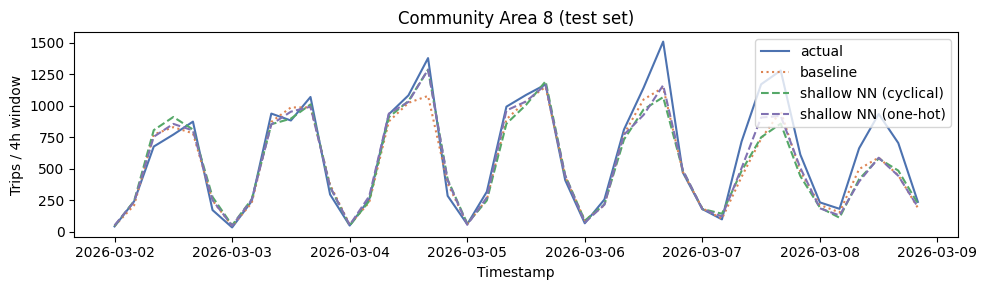

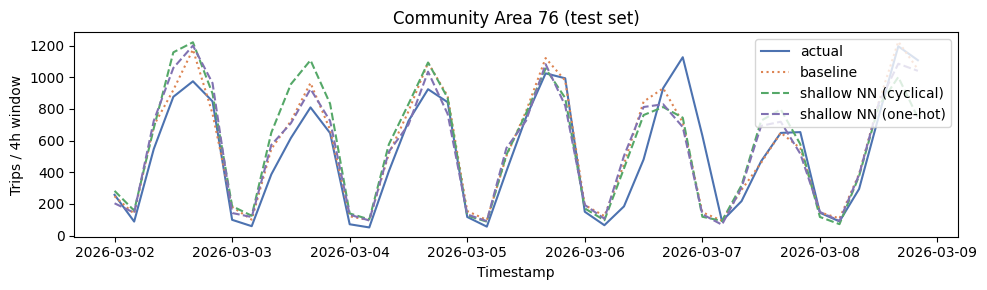

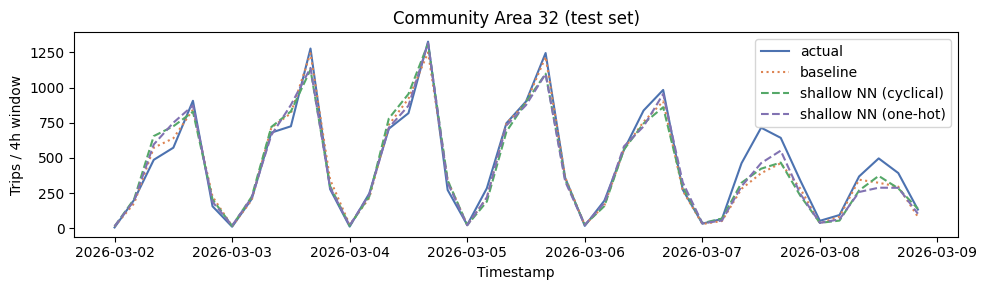

In [46]:
test_plot_pred_nn_ce = predict_counts(shallow_model_ce, test_plot[CE_ALL_COLS])
test_plot_pred_nn_oh = predict_counts(shallow_model_oh, test_plot[OH_ALL_COLS])

for area in top_3_areas:
    mask = test_plot["community_area"] == area
    area_val = test_plot[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=CATEGORICAL_COLORS[0])
    ax.plot(area_val["timestamp"], test_plot_pred_base[mask], label="baseline",
            color=CATEGORICAL_COLORS[1], linestyle=":")
    ax.plot(area_val["timestamp"], test_plot_pred_nn_ce[mask], label="shallow NN (cyclical)",
            color=CATEGORICAL_COLORS[2], linestyle="--")
    ax.plot(area_val["timestamp"], test_plot_pred_nn_oh[mask], label="shallow NN (one-hot)",
            color=CATEGORICAL_COLORS[4], linestyle="--")
    ax.set_title(f"Community Area {area} (test set)")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Trips / 4h window")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


All three predictions are nearly indistinguishable and track the daily double-peak cycle well.
Like the baseline, both NNs underestimate the strongest weekend peaks.


### 3.3 Baseline vs Shallow NN -- Metric Comparison

Both Shallow NN variants against the weighted baseline on the test set.


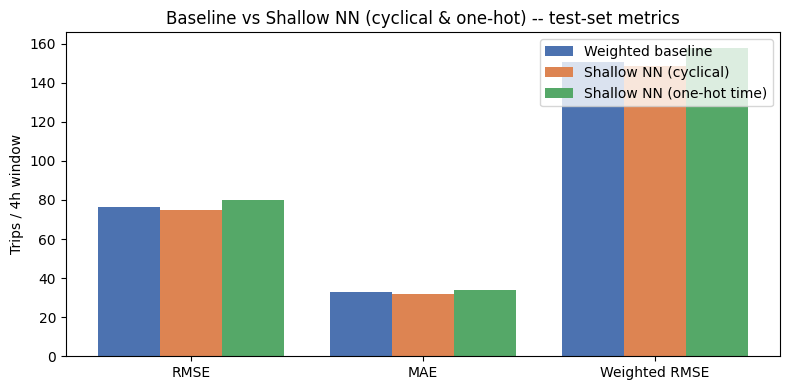

In [47]:
cmp_df = pd.DataFrame(all_results[:3]).set_index("model")
metrics, labels = ["test_rmse", "test_mae", "test_weighted_rmse"], ["RMSE", "MAE", "Weighted RMSE"]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(metrics))
n_models = len(cmp_df)
width = 0.8 / n_models
for i, model in enumerate(cmp_df.index):
    ax.bar(x + i * width, cmp_df.loc[model, metrics], width, label=model, color=CATEGORICAL_COLORS[i])
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(labels)
ax.set_ylabel("Trips / 4h window")
ax.set_title("Baseline vs Shallow NN (cyclical & one-hot) -- test-set metrics")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


Neither NN variant beats the baseline on RMSE or weighted RMSE. The cyclical variant does edge
the baseline on MAE (32.7 vs 32.9): it is as good on typical windows but misses the extreme
peaks by more, which the squared-error metrics punish harder.


### 3.4 Cyclical vs One-Hot Time Encoding -- Feature Importance & Metric Comparison

Test-set metrics head-to-head, and top features by permutation importance (how much shuffling a
feature degrades weighted RMSE) -- an NN has no per-feature coefficients to read off, unlike
03.08's LinearSVR.


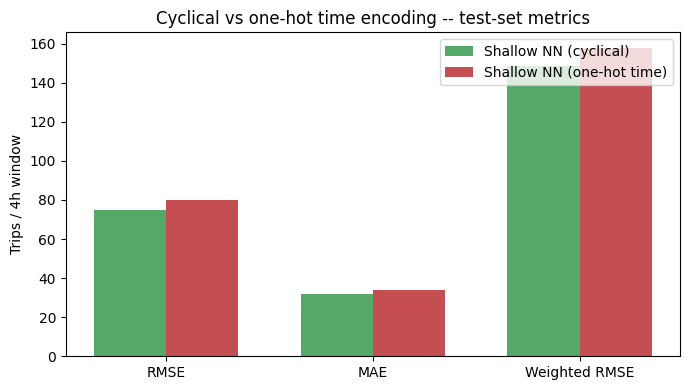

In [48]:
cmp_df_time = pd.DataFrame(all_results[1:3]).set_index("model")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(metrics))
width = 0.35
for i, model in enumerate(cmp_df_time.index):
    ax.bar(x + i * width, cmp_df_time.loc[model, metrics], width, label=model, color=CATEGORICAL_COLORS[i + 2])
ax.set_xticks(x + width / 2)
ax.set_xticklabels(labels)
ax.set_ylabel("Trips / 4h window")
ax.set_title("Cyclical vs one-hot time encoding -- test-set metrics")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


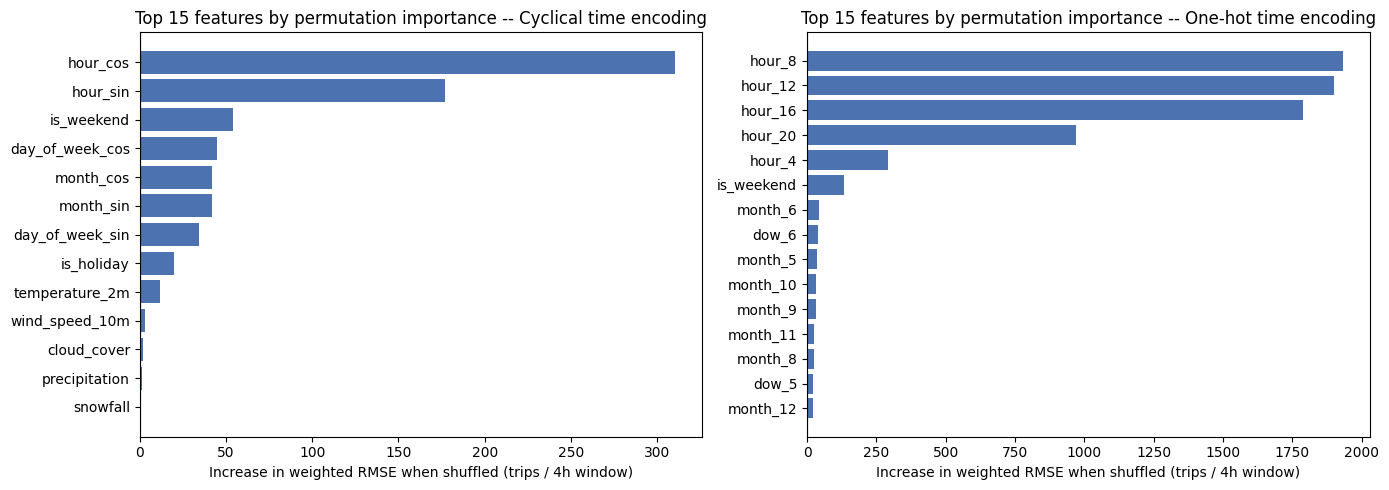

In [49]:
def permutation_importance_nn(model_wrapper, df, cols, n=15, n_repeats=3, seed=SEED):
    """Permutation importance: increase in weighted RMSE when a feature's values are shuffled
    (averaged over n_repeats). Area dummies are skipped, as in 03.08's coefficient plot."""
    rng = np.random.default_rng(seed)
    base_pred = predict_counts(model_wrapper, df[cols])
    base_score = evaluate(df, base_pred)["weighted_rmse"]

    rows = []
    for col in cols:
        if col.startswith("area"):
            continue
        deltas = []
        for _ in range(n_repeats):
            df_shuf = df.copy()
            df_shuf[col] = rng.permutation(df_shuf[col].to_numpy())
            pred = predict_counts(model_wrapper, df_shuf[cols])
            deltas.append(evaluate(df_shuf, pred)["weighted_rmse"] - base_score)
        rows.append({"feature": col, "importance": float(np.mean(deltas))})

    return pd.DataFrame(rows).sort_values("importance", ascending=False).head(n)


# Measured on nn_es, which never received weight updates; test stays reserved for final metrics.
top_imp_ce = permutation_importance_nn(shallow_model_ce, nn_es, CE_ALL_COLS)
top_imp_oh = permutation_importance_nn(shallow_model_oh, nn_es, OH_ALL_COLS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top_imp, title in [
    (axes[0], top_imp_ce, "Cyclical time encoding"),
    (axes[1], top_imp_oh, "One-hot time encoding"),
]:
    ax.barh(top_imp["feature"][::-1], top_imp["importance"][::-1], color=CATEGORICAL_COLORS[0])
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set_xlabel("Increase in weighted RMSE when shuffled (trips / 4h window)")
    ax.set_title(f"Top 15 features by permutation importance -- {title}")
plt.tight_layout()
plt.show()


The cyclical variant is slightly ahead on every test metric. Both importance panels tell the
same story: time of day dominates (hour_sin/hour_cos on the left, the hour dummies on the
right), is_weekend is a clear second, and the day-of-week/month features add little. Weather
contributes almost nothing -- demand in this panel is driven by the clock, not the sky.


## 4. Deep Neural Network

Two hidden layers, ReLU + dropout, weight decay via the optimizer. The candidate grid varies
**one factor at a time** around a reference configuration -- regularization strength up and
down (including a fully unregularized candidate, so depth isn't confounded with regularization:
the Shallow NN carries neither dropout nor weight decay) and network width up and down -- so
whichever candidate wins, the win is attributable to a single knob. Each candidate gets the
same early-stopped training run, and the best early-stopping loss becomes the final model.
Cyclical encoding only, to isolate architecture from encoding choice.


In [50]:
# One factor varied at a time around a reference config, so results are attributable to a
# single knob. The unregularized candidate deconfounds depth from regularization (the Shallow
# NN has neither dropout nor weight decay).
DEEP_REF = {"arch": "deep2", "hidden_dim1": 128, "hidden_dim2": 64, "dropout": 0.0, "weight_decay": 0}

deep_param_grid = [
    DEEP_REF,                                             # reference
    {**DEEP_REF, "dropout": 0.2},                         # add dropout
    {**DEEP_REF, "weight_decay": 1e-4},                   # add weight decay
    {**DEEP_REF, "dropout": 0.2, "weight_decay": 1e-4},   # add both
    {**DEEP_REF, "hidden_dim1": 64,  "hidden_dim2": 32},  # small network
    {**DEEP_REF, "hidden_dim1": 256, "hidden_dim2": 128}, # medium network
    {**DEEP_REF, "hidden_dim1": 512, "hidden_dim2": 256}, # large network
    {**DEEP_REF, "hidden_dim1": 1024, "hidden_dim2": 512}, # X-tra large network
    {"arch": "deep5", "hidden_dims": (512, 256, 128, 64, 32), "dropout": 0.0, "weight_decay": 0}, # 5 hidden layers
]

t0 = time.time()
prep_deep = make_preprocess(CE_CONT_FEATURES, AREA_DUMMY_COLS)
X_fit_deep, y_fit_deep = make_xy(nn_fit, CE_ALL_COLS, prep_deep, fit=True)
X_es_deep,  y_es_deep  = make_xy(nn_es,  CE_ALL_COLS, prep_deep, fit=False)

deep_search_rows = []
for hp in deep_param_grid:
    if hp["arch"] == "deep2":
        ctor = lambda hp=hp: DeepNet(
            len(CE_ALL_COLS), hidden_dim1=hp["hidden_dim1"],
            hidden_dim2=hp["hidden_dim2"], dropout=hp["dropout"]
        )
    else:
        ctor = lambda hp=hp: DeepNet5(
            len(CE_ALL_COLS), hidden_dims=hp["hidden_dims"], dropout=hp["dropout"]
        )

    model, best_epoch, best_es_loss = fit_with_early_stopping(
        ctor, X_fit_deep, y_fit_deep, X_es_deep, y_es_deep,
        lr=1e-3, weight_decay=hp["weight_decay"], label=str(hp),
    )
    deep_search_rows.append({**hp, "best_epoch": best_epoch, "es_loss": best_es_loss, "model": model})
fit_time_deep_search = time.time() - t0

deep_search_df = pd.DataFrame(deep_search_rows).sort_values("es_loss").reset_index(drop=True)
deep_search_df.drop(columns="model")  # the torch model objects themselves aren't displayable


{'arch': 'deep2', 'hidden_dim1': 128, 'hidden_dim2': 64, 'dropout': 0.0, 'weight_decay': 0}: stopped after 77 epochs (best epoch 69, early-stop loss 0.1182)
{'arch': 'deep2', 'hidden_dim1': 128, 'hidden_dim2': 64, 'dropout': 0.2, 'weight_decay': 0}: stopped after 84 epochs (best epoch 76, early-stop loss 0.1258)
{'arch': 'deep2', 'hidden_dim1': 128, 'hidden_dim2': 64, 'dropout': 0.0, 'weight_decay': 0.0001}: stopped after 59 epochs (best epoch 51, early-stop loss 0.1208)
{'arch': 'deep2', 'hidden_dim1': 128, 'hidden_dim2': 64, 'dropout': 0.2, 'weight_decay': 0.0001}: stopped after 69 epochs (best epoch 61, early-stop loss 0.1276)
{'arch': 'deep2', 'hidden_dim1': 64, 'hidden_dim2': 32, 'dropout': 0.0, 'weight_decay': 0}: stopped after 60 epochs (best epoch 52, early-stop loss 0.1213)
{'arch': 'deep2', 'hidden_dim1': 256, 'hidden_dim2': 128, 'dropout': 0.0, 'weight_decay': 0}: stopped after 30 epochs (best epoch 22, early-stop loss 0.1224)
{'arch': 'deep2', 'hidden_dim1': 512, 'hidden_di

,arch,hidden_dim1,hidden_dim2,dropout,weight_decay,best_epoch,es_loss,hidden_dims
0,deep2,1024.0,512.0,0.0,0.0000,44,0.117189,NaN
1,deep5,NaN,NaN,0.0,0.0000,31,0.117752,"(512, 256, 128, 64, 32)"
2,deep2,512.0,256.0,0.0,0.0000,37,0.118022,NaN
3,deep2,128.0,64.0,0.0,0.0000,69,0.118161,NaN
4,deep2,128.0,64.0,0.0,0.0001,51,0.120850,NaN
5,deep2,64.0,32.0,0.0,0.0000,52,0.121293,NaN
6,deep2,256.0,128.0,0.0,0.0000,22,0.122384,NaN
7,deep2,128.0,64.0,0.2,0.0000,76,0.125804,NaN
8,deep2,128.0,64.0,0.2,0.0001,61,0.127637,NaN


In [51]:
best_deep = deep_search_df.iloc[0]
print("Best Deep NN config:", {k: best_deep[k] for k in [
      "arch", "hidden_dim1", "hidden_dim2", "hidden_dims", "dropout", "weight_decay", "best_epoch"] if k in best_deep.index})

# The winning candidate's early-stopped model is used directly as the final model.
deep_model = TorchRegressor(best_deep["model"], prep_deep)
m_test_deep = evaluate(test, predict_counts(deep_model, test[CE_ALL_COLS]))
all_results.append(results_row("Deep NN (tuned)", m_test_deep, fit_time_deep_search))
print("Deep NN (tuned): test=", m_test_deep)


Best Deep NN config: {'arch': 'deep2', 'hidden_dim1': np.float64(1024.0), 'hidden_dim2': np.float64(512.0), 'hidden_dims': nan, 'dropout': np.float64(0.0), 'weight_decay': np.float64(0.0), 'best_epoch': np.int64(44)}
Deep NN (tuned): test= {'rmse': 78.53625390190429, 'mae': 33.28508420144126, 'weighted_rmse': 157.02737808054442}


The search favors the least-regularized candidate (dropout 0.2, weight decay 1e-4, best epoch
61); the heavily regularized one is clearly worst. The winner's early-stopping loss (0.128)
already trails Shallow NN cyclical's (0.125), and its test RMSE of 82.1 is the worst of all
models -- the extra capacity does not pay off here.


### 4.1 Baseline vs Deep NN -- Metric Comparison

The tuned Deep NN against the weighted baseline on the test set.


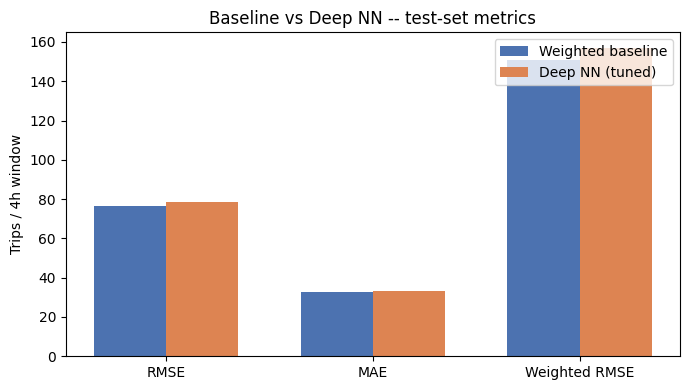

In [52]:
cmp_df_deep = pd.DataFrame([r for r in all_results
                            if r["model"] in ("Weighted baseline", "Deep NN (tuned)")]).set_index("model")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(metrics))
width = 0.35
for i, model in enumerate(cmp_df_deep.index):
    ax.bar(x + i * width, cmp_df_deep.loc[model, metrics], width, label=model, color=CATEGORICAL_COLORS[i])
ax.set_xticks(x + width / 2)
ax.set_xticklabels(labels)
ax.set_ylabel("Trips / 4h window")
ax.set_title("Baseline vs Deep NN -- test-set metrics")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### 4.2 All Models -- Test RMSE Comparison

Baseline, both Shallow NN encodings, and the tuned Deep NN.


In [53]:
results_df = pd.DataFrame(all_results)
results_df


,model,fit_time_s,test_rmse,test_mae,test_weighted_rmse
0,Weighted baseline,0.02,76.362685,32.902769,150.861463
1,Shallow NN (cyclical),90.16,75.027718,32.111395,148.775957
2,Shallow NN (one-hot time),66.30,79.926813,33.989237,157.912236
3,Deep NN (tuned),576.80,78.536254,33.285084,157.027378


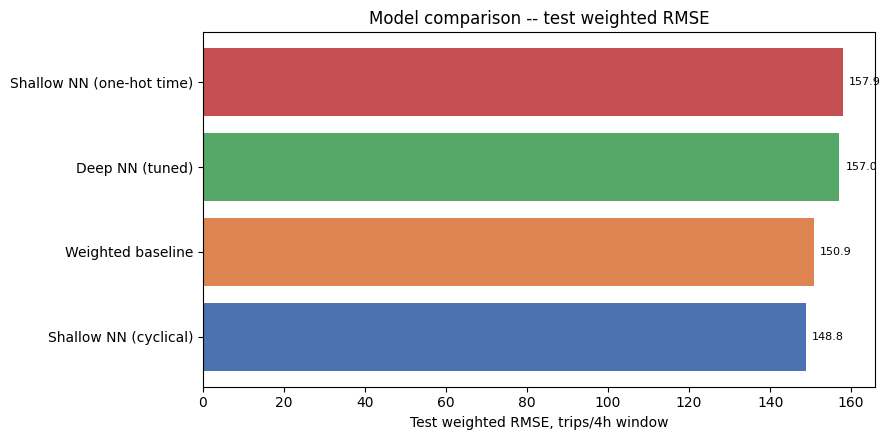

In [54]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = results_df.sort_values("test_weighted_rmse")["model"]
bar_vals = results_df.set_index("model").loc[order, "test_weighted_rmse"]
bars = ax.barh(order, bar_vals, color=CATEGORICAL_COLORS[: len(order)])
ax.set_xlabel("Test weighted RMSE, trips/4h window")
ax.set_title("Model comparison -- test weighted RMSE")
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2, f"{val:,.1f}",
            va="center", ha="left", fontsize=8)
plt.tight_layout()
plt.show()


Final ranking on test RMSE: baseline (76.4) < Shallow NN cyclical (77.1) < Shallow NN one-hot
(79.9) < Deep NN (82.1). No network beats the per-(area, time-bucket) median, and more model
complexity consistently ranks worse -- while the baseline fits in milliseconds and the networks
take 1.5-3 minutes. The exogenous features carry little signal beyond the calendar structure
the baseline already memorizes.


### 4.3 Export Results

Append this run's four models (community area, 4h) to the shared
`model_results_summary.csv`, so they can be compared against 03.01's SVM notebook in one
place. Reruns overwrite this notebook's own prior rows (matched on model + notebook +
resolution) rather than duplicating them. No per-area detail file yet -- this notebook
doesn't compute a per-area skill score (see the "Skill score berechnen" TODO), so
`skill_demand_weighted` and `skill_median` are left blank until that lands.

In [ ]:
RESULTS_DIR = pathlib.Path("../../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_CSV = RESULTS_DIR / "model_results_summary.csv"
NOTEBOOK_NAME = "03.05_prediction_nn_CA_4h.ipynb"


def upsert_csv(df_new, path, key_cols):
    """Append df_new to the CSV at `path`, replacing any existing rows with the same key_cols
    (so reruns update in place instead of duplicating) -- creates the file if it doesn't exist."""
    if path.exists():
        df_old = pd.read_csv(path)
        old_keys = df_old[key_cols].apply(tuple, axis=1)
        new_keys = set(df_new[key_cols].apply(tuple, axis=1))
        df_out = pd.concat([df_old[~old_keys.isin(new_keys)], df_new], ignore_index=True)
    else:
        df_out = df_new
    df_out.to_csv(path, index=False)
    return df_out


run_timestamp = pd.Timestamp.now().isoformat(timespec="seconds")

summary_df = pd.DataFrame([
    {
        "model_name": r["model"],
        "notebook": NOTEBOOK_NAME,
        "spatial_resolution": "community_area",
        "temporal_resolution": FREQ,
        "n_units": len(included_areas),
        "train_start": DATA_START.date().isoformat(),
        "train_end": (TEST_START - pd.Timedelta(days=1)).date().isoformat(),
        "test_start": TEST_START.date().isoformat(),
        "test_end": (DATA_END_EXCL - pd.Timedelta(days=1)).date().isoformat(),
        "rmse": r["test_rmse"],
        "mae": r["test_mae"],
        "r2": r["test_r2"],
        "weighted_rmse": r["test_weighted_rmse"],
        "skill_demand_weighted": None,
        "skill_median": None,
        "fit_time_s": r["fit_time_s"],
        "last_run_at": run_timestamp,
    }
    for r in all_results
])

upsert_csv(summary_df, SUMMARY_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution"])

print(f"Wrote {len(summary_df)} rows to {SUMMARY_CSV}")
summary_df


## 5. Discussion

**Strengths.** A hidden layer can combine area identity with time features non-linearly, so
area-specific demand shapes can be learned from the plain feature set -- 03.08's Linear SVM
cannot do this without hand-built interaction terms. Training cost scales linearly with rows:
no kernel-matrix wall, no subsampling needed.

**Weaknesses.** The tuning surface is large (architecture, learning rate, batch size, dropout,
weight decay, and epochs all interact) and Section 4's grid covers only a small slice of it.
Areas are one-hot encoded rather than embedded, so all areas are treated as unrelated
categories.

**Comparison to 03.08.** Both notebooks share features, baseline, and metrics, so Section 4.2's
`results_df` reads directly against 03.08's model comparison.

**Possible improvements:** learned area embeddings instead of one-hot dummies; a larger joint
hyperparameter search; a second harmonic in the cyclical encoding; lag features (deliberately
excluded here -- adding them would change the task from exogenous prediction to autoregression).
